In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import sys
sys.path.insert(0, "/home/quantumer/dmde_class_perturb-CEDE/python/build/lib.linux-x86_64-3.10")
import os
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import math
basedir = os.path.abspath('./')
gdmdir = os.path.join('../gdm_files')

import num2tex
from matplotlib import rc
import pandas as pd



lmax=3500
g=open('../gdm_files/w_T.dat') 
a=[]
w=[] 
dwda=[] 
alpha_min=[] 

for line in g:
    a.append(float(line.split()[0])) 
    w.append(float(line.split()[1])) 
    dwda.append(float(line.split()[2])) 
NT=np.size(w)

w_arr=np.array(w)
a_arr=np.array(a)
dwda_arr=np.array(dwda)





In [2]:



#necessary additions for sound speed superhorizon ccausality stuff
h=open('../gdm_files/k_values.dat') 
kvals=[] 
for line in h: 
    kvals.append(float(line.split()[0])) 
NK=np.size(kvals) 
#NC=10

cs2_1d=[]  
cs2_2d=np.zeros((NT,NK))
jj=open('../gdm_files/cs2_T.dat')
cc=0
for line in jj:
    cs2_1d.append(float(line.split()[0]))
    iplace=cc//NK
    jplace=cc%NK
    cs2_2d[iplace,jplace]=cs2_1d[cc]
    cc+=1
    
cs2_1d_array=np.asarray(cs2_1d)
#print(np.shape(cs2_2d))

In [3]:
# esthetic definitions for the plots
t0_cmb=2.725
lmax=3500
factor = 1.e12*(t0_cmb**2)
font = {'size'   : 16, 'family':'STIXGeneral'}
axislabelfontsize='large'
matplotlib.rc('font', **font)
#matplotlib.mathtext.rcParams['legend.fontsize']='medium'
plt.rcParams["figure.figsize"] = [8.0,6.0]
factor = 1.e12*(t0_cmb**2)

3.63
[[ 3.33306949e-01  3.33306949e-01  3.33306949e-01 ...  3.33306949e-01
   3.33306949e-01  3.33306949e-01]
 [ 3.33306874e-01  3.33306874e-01  3.33306874e-01 ...  3.33306874e-01
   3.33306874e-01  3.33306874e-01]
 [ 3.33306799e-01  3.33306799e-01  3.33306799e-01 ...  3.33306799e-01
   3.33306799e-01  3.33306799e-01]
 ...
 [ 8.79947569e-05  8.80651270e-05  8.79698636e-05 ...  6.35603512e-12
   6.21696942e-12  6.15787031e-12]
 [ 6.57652545e-05  6.57684972e-05  6.57109363e-05 ... -3.98243535e-12
  -3.92297180e-12 -3.93242027e-12]
 [ 2.24147396e-05  2.24147583e-05  2.24090659e-05 ...  4.32705968e-12
   4.24979835e-12  4.16831283e-12]]


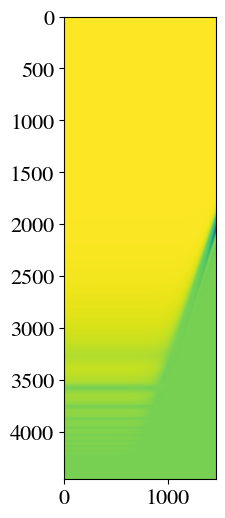

In [4]:

plt.imshow(cs2_2d)
#print(np.shape(cs2_2d))
#print(NK*NT)
def coarse_dcs2(NCx,NCy,ij_pairs,vals):
    array=np.zeros((NCx,NCy))
    for k in range(np.size(ij_pairs[:,0])):
      #  print(np.shape(ij_pairs))
       # print(np.shape(array))
      #  print(ij_pairs[k,0],ij_pairs[k,1])
        array[int(ij_pairs[k,0]),int(ij_pairs[k,1])]=vals[k]
    return array

def fine_dcs2(NT,NK,NCx,NCy,coarse_grid,kvals,a_arr,epsilon,shape):
    width=NK/NCy
    height=NT/NCx
  
    k_lbounds=[]
    k_ubounds=[]
    for jj in range(NCy):
        k_lbounds.append(int(jj*width)+epsilon)
        k_ubounds.append(int(jj*width+width)+epsilon)
    k_ubounds[NCy-1]=NK-1+epsilon
    
    a_lbounds=[]
    a_ubounds=[]
    for ii in range(NCx):
        a_lbounds.append(int(ii*height)+epsilon)
        a_ubounds.append(int(ii*height+height)+epsilon)
    a_ubounds[NCx-1]=NT-1+epsilon    
    q=np.zeros((NT,NK))
 #   print(k_ubounds)
 #   print(a_ubounds)
    av=a_arr[epsilon:NT+epsilon]
    kv=kvals[epsilon:NK+epsilon]
    for i in range(NCx):
        acen=np.log((a_arr[int(a_lbounds[i])]+a_arr[int(a_ubounds[i])])*0.5)
        dela= -(np.log(a_arr[int(a_lbounds[i])])-np.log(a_arr[int(a_ubounds[i])]))/4.710

        arga=0.5*np.power((np.array(np.log(av))-acen)/dela,2.0e0)
        for j in range(NCy):
            kcen=(np.log(kvals[int(k_lbounds[j])])+np.log(kvals[int(k_ubounds[j])]))*0.5
            delk= -(np.log(kvals[int(k_lbounds[j])])-np.log(kvals[int(k_ubounds[j])]))/4.710

            argk=0.5*np.power((np.log(np.array(kv))-kcen)/delk,2.0e0)
           # print(arga)
            #print(np.exp(-max(arg)),np.exp(-min(arg)),np.exp(-min(arga)),np.exp(-max(arga)))
            kfa,afa= np.meshgrid(argk,arga)
#            # print(np.shape(kfa))
#            # print(np.shape(afa))
            if (coarse_grid[i,j]!=0.e0):
                if (shape=='gauss'):
                    q=coarse_grid[i,j]*np.exp(-kfa)*np.exp(-afa)/np.sqrt(4*np.pi*np.power(dela,2.e0))
                else:
                    q[a_lbounds[i]-epsilon:a_ubounds[i]-epsilon,k_lbounds[j]-epsilon:k_ubounds[j]-epsilon]=coarse_grid[i,j]/(dela*4.710)
#                 print('kl', kvals[int(k_lbounds[j])],'kr',kvals[int(k_ubounds[j])],'al',a_arr[int(a_lbounds[i])],'ar',a_arr[int(a_ubounds[i])])
    
    return q
            # print(width,height)



def pixel_coarse(NT,NK,NCx,NCy,kbin,tbin,epsilon,kvals,a_arr):
    NKuse=NK-2*epsilon
    NTuse=NT-2*epsilon
    width=NKuse/NCy
    height=NTuse/NCx
    
    k_lbounds=[]
    k_ubounds=[]
    for ii in range(NCx):
        k_lbounds.append(int(ii*width))
        k_ubounds.append(int(ii*width+width))
    k_ubounds[NCx-1]=NKuse
    
    a_lbounds=[]
    a_ubounds=[]
    for jj in range(NCy):
        a_lbounds.append(int(jj*height))
        a_ubounds.append(int(jj*height+height))
    a_ubounds[NCy-1]=NTuse   
#    print('r',a_lbounds
#    print (k_lbounds[kbin],k_ubounds[kbin],a_lbounds[tbin],a_ubounds[tbin])
#    print(kbin*width+epsilon,kbin*width+epsilon+width,tbin*height+epsilon,tbin*height+epsilon+height)
 #   return [0,0,0,0]
    return float(kvals[k_lbounds[int(kbin)]+epsilon]),float(kvals[k_ubounds[int(kbin)]+epsilon]),float(a_arr[a_lbounds[int(tbin)]+epsilon]),float(a_arr[a_ubounds[int(tbin)]+epsilon])
#kl,kr,al,ar=pixel_coarse(749,1464,10,10,9,9,8,kvals,a_arr)
#print(kl,kr,al,ar)

import decimal
        
def value_to_decimal(value, decimal_places):
    decimal.getcontext().rounding = decimal.ROUND_HALF_UP  # define rounding method
    return decimal.Decimal(str(float(value))).quantize(decimal.Decimal('1e-{}'.format(decimal_places)))

print(value_to_decimal(3.63321,2))
print(cs2_2d)

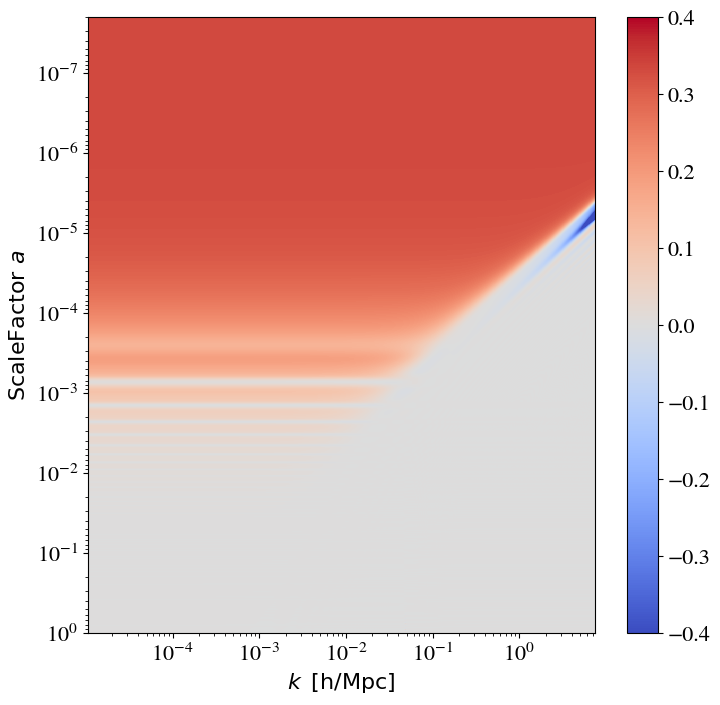

In [5]:
ya=3
xa=7
ij_pairs=np.array([[ya,xa]]).astype(int)
vals=np.array([0.3])
K,T= np.meshgrid(kvals,a_arr)
#print(np.shape(K),np.shape(T))
#print(np.shape(kvals))
fig = plt.figure(figsize=(18,8)) 
cs2h = fig.add_subplot(121)
#

#kl,kr,al,ar=pixel_coarse(NT,NK,20,20,xa,ya,0,kvals,a_arr)
#print(kl,kr,al,ar)
# Add the patch to the Axes
  
fig_cs2h = cs2h.pcolormesh(K,T,cs2_2d,cmap='coolwarm',vmax=0.4,vmin=-0.4) #,shading='gouraud')
#rect = patches.Rectangle((kl, al), kr-kl, ar-al, linewidth=1, edgecolor='r', facecolor='none')
#fig_cs2h = cs2h.pcolormesh(K,T,cs2_2d)
#cs2h.add_patch(rect)

cs2h.set_xlim(kvals[0],kvals[-1])
#cs2h.set_ylim([3.04e-8,1.e0])
cs2h.set_xscale('log')
cs2h.set_yscale('log')
cs2h.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
cs2h.set_ylabel(r'${\rm Scale Factor~} a$')
cs2h.invert_yaxis()
fig.colorbar(fig_cs2h)
#+fine_dcs2(2999,1464,10,10,coarse_dcs2(10,10,ij_pairs,vals),'kick')

Text(0, 0.5, 'CEDE Sound Speed')

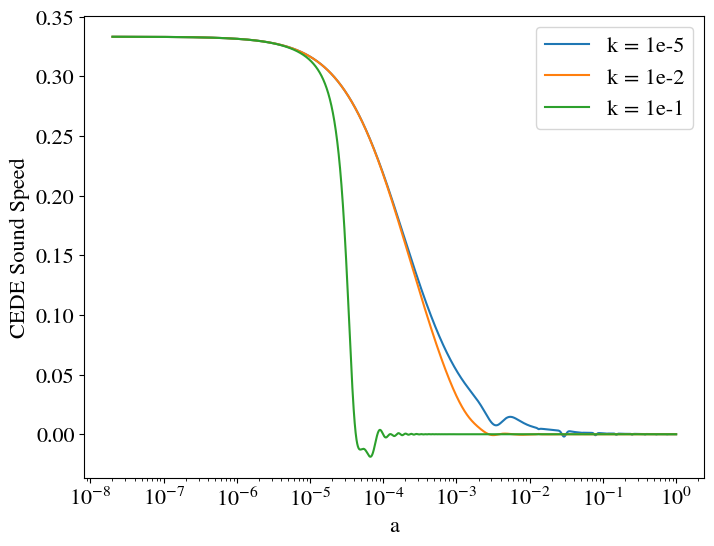

In [6]:
plt.plot(T.T[0],cs2_2d.T[0],label='k = 1e-5')
plt.plot(T.T[800],cs2_2d.T[800],label='k = 1e-2')
plt.plot(T.T[1200],cs2_2d.T[1200],label='k = 1e-1')
plt.legend()
plt.xscale('log')
plt.xlabel('a')
plt.ylabel('CEDE Sound Speed')
#plt.yscale('log')

In [7]:
np.savetxt('kval_frac_0.1.csv',K)
np.savetxt('aval_frac_0.1.csv',T)
np.savetxt('sound_speed_frac_0.1.csv',cs2_2d)

In [8]:

#
# find the global extra of Theta0(tau,k) and phi(tau,k), used to define color code later
#
Theta_amp = max(Theta0_kick.max(),-Theta0_kick.min()) 
phi_amp = max(phi_kick.max(),-phi_kick.min()) 
#
# reshaping of (k,tau) necessary to call the function 'pcolormesh'
#
K,T = np.meshgrid(k,tau)
#
# inform user of the size of the grids (related to the figure resolution)
#
print ('grid size:',len(k),len(tau),Theta0_kick.shape)
#
#################
#
# start plotting
#
#################
fig = plt.figure(figsize=(18,18)) 
#

#
ax_Theta = fig.add_subplot(221)
print ('> Plotting Theta_0')
fig_Theta = ax_Theta.pcolormesh(K,T,Theta0_kick,cmap='coolwarm',vmin=-Theta_amp,vmax=Theta_amp) #,shading='gouraud')
 #,shading='gouraud')

rect = patches.Rectangle((kl, tauofa(al)), kr-kl, tauofa(ar)-tauofa(al), linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax_Theta.add_patch(rect)



print ('> Done')
# plot lines (characteristic times and scales)
#
ax_Theta.axhline(y=tau_rec,color='k',linestyle='-')
ax_Theta.axhline(y=tau_eq,color='k',linestyle='-')
ax_Theta.axhline(y=tau_lambda,color='k',linestyle='-')
ax_Theta.plot(aH,tau,'r-',linewidth=2)
ax_Theta.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
ax_Theta.plot(kd,tau,'b-',linewidth=2)
#
# dealing with labels
#
ax_Theta.set_title(r'$\Theta_0$')
ax_Theta.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_Theta.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_Theta.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_Theta.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_Theta.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_Theta.annotate(r'$\mathrm{damping} \,\, \mathrm{scale} \,\, \mathrm{cross.}$',
                  xy=(thermodynamics_kd_at_tau(tau_label_kd),tau_label_kd),
                  xytext=(0.2*thermodynamics_kd_at_tau(tau_label_kd),2.0*tau_label_kd),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_Theta.set_xlim(k[0],k[-1])
ax_Theta.set_xscale('log')
ax_Theta.set_yscale('log')
ax_Theta.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
ax_Theta.set_ylabel(r'$\tau   \,\,\, \mathrm{[Mpc]}$')
ax_Theta.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_Theta)
#
# plot phi(k,tau)
#
ax_phi = fig.add_subplot(222)
ax_phi.set_xlim(k[0],k[-1])
print ('> Plotting phi')
fig_phi = ax_phi.pcolormesh(K,T,phi_kick,cmap='coolwarm',vmin=-phi_amp, vmax=phi_amp)
rect = patches.Rectangle((kl, tauofa(al)), kr-kl, tauofa(ar)-tauofa(al), linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax_phi.add_patch(rect)
print ('> Done')
#
# plot lines (characteristic times and scales)
#
ax_phi.axhline(y=tau_rec,color='k',linestyle='-')
ax_phi.axhline(y=tau_eq,color='k',linestyle='-')
ax_phi.axhline(y=tau_lambda,color='k',linestyle='-')
ax_phi.plot(aH,tau,'r-',linewidth=2)
ax_phi.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
#
# dealing with labels
#
ax_phi.set_title(r'$\phi$')
ax_phi.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_phi.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_phi.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_phi.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_phi.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_phi.set_xscale('log')
ax_phi.set_yscale('log')
ax_phi.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_phi.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_phi.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_phi)

ax_dg = fig.add_subplot(223)
ax_dg.set_xlim(k[0],k[-1])
print ('> Plotting dfld')
fig_dg = ax_dg.pcolormesh(K,T,np.log10(np.abs(dgdm_kick)),cmap='coolwarm',vmin=-4.,vmax=4.)
rect = patches.Rectangle((kl, tauofa(al)), kr-kl, tauofa(ar)-tauofa(al), linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax_dg.add_patch(rect)
print ('> Done')
#
# plot lines (characteristic times and scales)
#
ax_dg.axhline(y=tau_rec,color='k',linestyle='-')
ax_dg.axhline(y=tau_eq,color='k',linestyle='-')
ax_dg.axhline(y=tau_lambda,color='k',linestyle='-')
ax_dg.plot(aH,tau,'r-',linewidth=2)
ax_dg.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
#
# dealing with labels
#
ax_dg.set_title(r'$\log_{10}{|\delta_{\rm fld}|}$')
ax_dg.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_dg.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_dg.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_dg.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_dg.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_dg.set_xscale('log')
ax_dg.set_yscale('log')
ax_dg.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_dg.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_dg.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_dg)

ax_vg = fig.add_subplot(224)
ax_vg.set_xlim(k[0],k[-1])
#ax_phi.pcolor(K,T,phi,cmap='coolwarm')
print ('> Plotting vfld')
fig_vg = ax_vg.pcolormesh(K,T,vdm_kick,cmap='coolwarm')
rect = patches.Rectangle((kl, tauofa(al)), kr-kl, tauofa(ar)-tauofa(al), linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax_vg.add_patch(rect)
print ('> Done')
#
# plot lines (characteristic times and scales)
# #
ax_vg.axhline(y=tau_rec,color='k',linestyle='-')
ax_vg.axhline(y=tau_eq,color='k',linestyle='-')
ax_vg.axhline(y=tau_lambda,color='k',linestyle='-')
ax_vg.plot(aH,tau,'r-',linewidth=2)
ax_vg.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
# #
# # dealing with labels
# #
ax_vg.set_title(r'$v_{\rm fld}$')
ax_vg.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_vg.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_vg.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_vg.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_vg.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_vg.set_xscale('log')
ax_vg.set_yscale('log')
ax_vg.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_vg.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_vg.invert_yaxis()
# #
# # color legend
# #
fig.colorbar(fig_vg)
# #
# #


#
# produce the PDF
plt.savefig('evolution_pixel1_kick.png',dpi=300)

plt.show()
#plt.savefig('many_times.png',dpi=300)
plt.close()




NameError: name 'Theta0_kick' is not defined

In [ ]:
print(k[k_j_target]*tau)
print(tau)

In [ ]:
## Theta_amp = max(Theta0_fid.max(),-Theta0_fid.min()) 
phi_amp = max(phi_fid.max(),-phi_fid.min()) 
#
# reshaping of (k,tau) necessary to call the function 'pcolormesh'
#
K,T = np.meshgrid(k,tau)
#
# inform user of the size of the grids (related to the figure resolution)
#
print ('grid size:',len(k),len(tau),Theta0_fid.shape)
#
#################
#
# start plotting
#
#################
fig = plt.figure(figsize=(18,18)) 
#
# plot Theta0(k,tau)
#
ax_Theta = fig.add_subplot(221)
print ('> Plotting Theta_0')
fig_Theta = ax_Theta.pcolormesh(K,T,Theta0_fid,cmap='coolwarm') #,shading='gouraud')
print ('> Done')
#
# plot lines (characteristic times and scales)
#
ax_Theta.axhline(y=tau_rec,color='k',linestyle='-')
ax_Theta.axhline(y=tau_eq,color='k',linestyle='-')
ax_Theta.axhline(y=tau_lambda,color='k',linestyle='-')
ax_Theta.plot(aH,tau,'r-',linewidth=2)
ax_Theta.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
ax_Theta.plot(kd,tau,'b-',linewidth=2)
#
# dealing with labels
#
ax_Theta.set_title(r'$\Theta_0$')
ax_Theta.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_Theta.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_Theta.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_Theta.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_Theta.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_Theta.annotate(r'$\mathrm{damping} \,\, \mathrm{scale} \,\, \mathrm{cross.}$',
                  xy=(thermodynamics_kd_at_tau(tau_label_kd),tau_label_kd),
                  xytext=(0.2*thermodynamics_kd_at_tau(tau_label_kd),2.0*tau_label_kd),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_Theta.set_xlim(k[0],k[-1])
ax_Theta.set_xscale('log')
ax_Theta.set_yscale('log')
ax_Theta.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
ax_Theta.set_ylabel(r'$\tau   \,\,\, \mathrm{[Mpc]}$')
ax_Theta.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_Theta)
#

#
ax_phi = fig.add_subplot(222)
ax_phi.set_xlim(k[0],k[-1])
print ('> Plotting phi')
fig_phi = ax_phi.pcolormesh(K,T,phi_fid,cmap='coolwarm',vmin=-phi_amp, vmax=phi_amp)
print ('> Done')
#
# plot lines (characteristic times and scales)
#
ax_phi.axhline(y=tau_rec,color='k',linestyle='-')
ax_phi.axhline(y=tau_eq,color='k',linestyle='-')
ax_phi.axhline(y=tau_lambda,color='k',linestyle='-')
ax_phi.plot(aH,tau,'r-',linewidth=2)
ax_phi.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
#
# dealing with labels
#
ax_phi.set_title(r'$\phi$')
ax_phi.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_phi.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_phi.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_phi.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_phi.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_phi.set_xscale('log')
ax_phi.set_yscale('log')
ax_phi.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_phi.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_phi.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_phi)

ax_dg = fig.add_subplot(223)
ax_dg.set_xlim(k[0],k[-1])
print ('> Plotting dfld')
fig_dg = ax_dg.pcolormesh(K,T,np.log10(np.abs(dgdm_fid)),cmap='coolwarm',vmin=-4,vmax=4)
print ('> Done')
#
# plot lines (characteristic times and scales)
#
ax_dg.axhline(y=tau_rec,color='k',linestyle='-')
ax_dg.axhline(y=tau_eq,color='k',linestyle='-')
ax_dg.axhline(y=tau_lambda,color='k',linestyle='-')
ax_dg.plot(aH,tau,'r-',linewidth=2)
ax_dg.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
#
# dealing with labels
#
ax_dg.set_title(r'$\log_{10}{|\delta_{\rm fld}|}$')
ax_dg.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_dg.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_dg.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_dg.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_dg.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_dg.set_xscale('log')
ax_dg.set_yscale('log')
ax_dg.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_dg.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_dg.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_dg)

ax_vg = fig.add_subplot(224)
ax_vg.set_xlim(k[0],k[-1])
print ('> Plotting vfld')
fig_vg = ax_vg.pcolormesh(K,T,vdm_fid,cmap='coolwarm')
print ('> Done')
#
# plot lines (characteristic times and scales)
# #
ax_vg.axhline(y=tau_rec,color='k',linestyle='-')
ax_vg.axhline(y=tau_eq,color='k',linestyle='-')
ax_vg.axhline(y=tau_lambda,color='k',linestyle='-')
ax_vg.plot(aH,tau,'r-',linewidth=2)
ax_vg.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
# #
# # dealing with labels
# #
ax_vg.set_title(r'$v_{\rm fld}$')
ax_vg.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_vg.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_vg.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_vg.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_vg.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_vg.set_xscale('log')
ax_vg.set_yscale('log')
ax_vg.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_vg.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_vg.invert_yaxis()
# #
# # color legend
# #
fig.colorbar(fig_vg)
plt.savefig('evolution_pixel1_fiducial.png',dpi=300)
plt.show()
# plt.savefig('many_times_b.png',dpi=300)


plt.close()

print('I am Theta_amp',Theta_amp)

u=Delta_Theta0/Theta0_fid
Theta_amp = max(u.max(),-u.min())


phi_amp = max(Delta_phi.max(),-Delta_phi.min()) 
#
# reshaping of (k,tau) necessary to call the function 'pcolormesh'
#
K,T = np.meshgrid(k,tau)
#
# inform user of the size of the grids (related to the figure resolution)
#
print ('grid size:',len(k),len(tau),Theta0_fid.shape)
#
#################
#
# start plotting
#
#################
fig = plt.figure(figsize=(18,18)) 
#
# plot Theta0(k,tau)





In [ ]:
Delta_Theta0=Theta0_kick-Theta0_fid
Delta_dgdm=dgdm_kick-dgdm_fid
Delta_vdm=vdm_kick-vdm_fid
Delta_phi=phi_kick-phi_fid




u=Delta_Theta0/Theta0_fid
Theta_amp = max(u.max(),-u.min())
print('I am Theta_amp',Theta_amp)

phi_amp = max(Delta_phi.max(),-Delta_phi.min()) 
#
# reshaping of (k,tau) necessary to call the function 'pcolormesh'
#
K,T = np.meshgrid(k,tau)
#
# inform user of the size of the grids (related to the figure resolution)
#
# print ('grid size:',len(k),len(tau),Theta0_fid.shape)
#
#################
#
# start plotting
#
#################
fig = plt.figure(figsize=(18,18)) 
#
# plot Theta0(k,tau)




ax_Theta = fig.add_subplot(221)
print ('> Plotting Theta_0')
fig_Theta = ax_Theta.pcolormesh(K,T,((Delta_Theta0/Theta0_fid)),cmap='coolwarm',vmin=-5.e-5,vmax=5.e-5)

rect = patches.Rectangle((kl, tauofa(al)), kr-kl, tauofa(ar)-tauofa(al), linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax_Theta.add_patch(rect)
print ('> Done')
#
# plot lines (characteristic times and scales)
#
ax_Theta.axhline(y=tau_rec,color='k',linestyle='-')
ax_Theta.axhline(y=tau_eq,color='k',linestyle='-')
ax_Theta.axhline(y=tau_lambda,color='k',linestyle='-')
ax_Theta.plot(aH,tau,'r-',linewidth=2)
ax_Theta.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
ax_Theta.plot(kd,tau,'b-',linewidth=2)
#
# dealing with labels
#
ax_Theta.set_title(r'$\Delta \Theta_0/\Theta_0$')
ax_Theta.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_Theta.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_Theta.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_Theta.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_Theta.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_Theta.annotate(r'$\mathrm{damping} \,\, \mathrm{scale} \,\, \mathrm{cross.}$',
                  xy=(thermodynamics_kd_at_tau(tau_label_kd),tau_label_kd),
                  xytext=(0.2*thermodynamics_kd_at_tau(tau_label_kd),2.0*tau_label_kd),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_Theta.set_xlim(k[0],k[-1])
ax_Theta.set_xscale('log')
ax_Theta.set_yscale('log')
ax_Theta.set_xlabel(r'$k  \,\,\, \mathrm{[h/Mpc]}$')
ax_Theta.set_ylabel(r'$\tau   \,\,\, \mathrm{[Mpc]}$')
ax_Theta.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_Theta)
#
#
ax_phi = fig.add_subplot(222)
ax_phi.set_xlim(k[0],k[-1])
print ('> Plotting phi')
fig_phi = ax_phi.pcolormesh(K,T,Delta_phi/phi_fid,cmap='coolwarm')

rect = patches.Rectangle((kl, tauofa(al)), kr-kl, tauofa(ar)-tauofa(al), linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax_phi.add_patch(rect)
print ('> Done')
#
# plot lines (characteristic times and scales)
#
ax_phi.axhline(y=tau_rec,color='k',linestyle='-')
ax_phi.axhline(y=tau_eq,color='k',linestyle='-')
ax_phi.axhline(y=tau_lambda,color='k',linestyle='-')
ax_phi.plot(aH,tau,'r-',linewidth=2)
ax_phi.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
#
# dealing with labels
#
ax_phi.set_title(r'$\Delta \phi/\phi$')
ax_phi.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_phi.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_phi.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_phi.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_phi.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_phi.set_xscale('log')
ax_phi.set_yscale('log')
ax_phi.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_phi.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_phi.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_phi)

ax_dg = fig.add_subplot(223)
ax_dg.set_xlim(k[0],k[-1])
print ('> Plotting dfld')
fig_dg = ax_dg.pcolormesh(K,T,Delta_dgdm/dgdm_fid,cmap='coolwarm')
rect = patches.Rectangle((kl, tauofa(al)), kr-kl, tauofa(ar)-tauofa(al), linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax_dg.add_patch(rect)
print ('> Done')
#
# plot lines (characteristic times and scales)
#
ax_dg.axhline(y=tau_rec,color='k',linestyle='-')
ax_dg.axhline(y=tau_eq,color='k',linestyle='-')
ax_dg.axhline(y=tau_lambda,color='k',linestyle='-')
ax_dg.plot(aH,tau,'r-',linewidth=2)
ax_dg.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
#
# dealing with labels
#
ax_dg.set_title(r'$\Delta\delta_{\rm fld}/\delta_{\rm fld}$')
ax_dg.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_dg.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_dg.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_dg.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_dg.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_dg.set_xscale('log')
ax_dg.set_yscale('log')
ax_dg.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_dg.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_dg.invert_yaxis()
#
# color legend
#
fig.colorbar(fig_dg)

ax_vg = fig.add_subplot(224)
ax_vg.set_xlim(k[0],k[-1])
print ('> Plotting vfld')
fig_vg = ax_vg.pcolormesh(K,T,Delta_vdm/vdm_fid,cmap='coolwarm')
rect = patches.Rectangle((kl, tauofa(al)), kr-kl, tauofa(ar)-tauofa(al), linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax_vg.add_patch(rect)
print ('> Done')
#
# plot lines (characteristic times and scales)
# #
ax_vg.axhline(y=tau_rec,color='k',linestyle='-')
ax_vg.axhline(y=tau_eq,color='k',linestyle='-')
ax_vg.axhline(y=tau_lambda,color='k',linestyle='-')
ax_vg.plot(aH,tau,'r-',linewidth=2)
ax_vg.plot(ks,tau,color='#FFFF33',linestyle='-',linewidth=2)
# #
# # dealing with labels
# #
ax_vg.set_title(r'$\Delta v_{\rm fld}$')
ax_vg.text(1.5*k[0],0.9*tau_rec,r'$\mathrm{rec.}$')
ax_vg.text(1.5*k[0],0.9*tau_eq,r'$\mathrm{R/M} \,\, \mathrm{eq.}$')
ax_vg.text(1.5*k[0],0.9*tau_lambda,r'$\mathrm{M/L} \,\, \mathrm{eq.}$')
ax_vg.annotate(r'$\mathrm{Hubble} \,\, \mathrm{cross.}$',
                  xy=(background_aH_at_tau(tau_label_Hubble),tau_label_Hubble),
                  xytext=(0.1*background_aH_at_tau(tau_label_Hubble),0.8*tau_label_Hubble),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
ax_vg.annotate(r'$\mathrm{sound} \,\, \mathrm{horizon} \,\, \mathrm{cross.}$',
                  xy=(background_ks_at_tau(tau_label_ks),tau_label_ks),
                  xytext=(0.07*background_aH_at_tau(tau_label_ks),0.8*tau_label_ks),
                  arrowprops=dict(facecolor='black', shrink=0.05, width=1, headlength=5, headwidth=5))
#
# dealing with axes
#
ax_vg.set_xscale('log')
ax_vg.set_yscale('log')
ax_vg.set_xlabel(r'$k \,\,\, \mathrm{[h/Mpc]}$')
ax_vg.set_ylabel(r'$\tau \,\,\, \mathrm{[Mpc]}$')
ax_vg.invert_yaxis()
# #
# # color legend
# #
fig.colorbar(fig_vg)
plt.savefig('evolution_pixel1_p_diff_kick.png',dpi=300)
plt.show()
#plt.savefig('many_times_3.png',dpi=300)
plt.close()


print(np.min(Delta_Theta0/Theta0_fid),np.max(Delta_Theta0/Theta0_fid))








In [ ]:
Delta_Theta0

In [ ]:
# for i in range(np.size(Theta0_fid[:,0])):
#     for j in range(np.size(Theta0_fid[0,:])):
#         if (np.abs(Delta_Theta0[i,j])>0):
#             print(Delta_Theta0[i,j]/Theta0_fid[i,j])
    

In [ ]:
print(np.min(Delta_Theta0/Theta0_fid))

In [ ]:
print(np.max(Delta_Theta0/Theta0_fid))

In [ ]:
u

In [ ]:
import dill
dill.dump_session('notebook_env.db')

In [ ]:
#dill.load_session('notebook_env.db')

In [ ]:
kl
print(k)
for j in range(1,k_num-1):
  #  print(kcen,k[j])
    if (k[j] < kcen):
        if (k[j+1] > kcen):
            k_j_target=j
for j in range(1,np.size(kvals)-1):
  #  print(kcen,k[j])
    if (kvals[j] < kcen):
        if (kvals[j+1] > kcen):
            k_n_target=j
            
print(k_n_target)
Theta0_fid_track=Theta0_fid[:,k_j_target]
phi_fid_track=phi_fid[:,k_j_target]
dgdm_fid_track=dgdm_fid[:,k_j_target]
vdm_fid_track=vdm_fid[:,k_j_target]
#plt.plot(tau,dgdm_fid_track)
plt.plot(k[k_j_target]*tau,np.abs(dgdm_track/dgdm_fid_track-1.),label=r'$\Delta \delta_{\rm fld}/\delta_{\rm fld}$',color='b')
#plt.plot(k[k_j_target]*tau,np.abs(vdm_track/vdm_fid_track-1.),label=r'$\Delta v_{\rm fld}/v_{\rm fld}$',color='orange')
#plt.plot(k[k_j_target]*tau,np.abs(phi_track/phi_fid_track-1.),label=r'$\Delta \phi/\phi,{\rm kick}$',color='forestgreen',linestyle=':')
plt.plot(k[k_j_target]*tau,np.abs(Theta0_track/Theta0_fid_track-1.),label=r'$\Delta \Theta_0 /\Theta_0$',color='m')
plt.plot(kcen*tauofa(a_arr),np.abs(cs2_2d_out[:,k_n_target]-cs2_2d[:,k_n_target]),label=r'$\Delta c_{s}^{2}$',color='k')

plt.plot(k[k_j_target]*tau,np.abs(dgdm_kick_track/dgdm_fid_track-1.),label=r'$\Delta \delta_{\rm fld}/\delta_{\rm fld},{\rm kick}$',color='b',linestyle=':')
#plt.plot(k[k_j_target]*tau,np.abs(vdm_kick_track/vdm_fid_track-1.),label=r'$\Delta v_{\rm fld}/v_{\rm fld},{\rm kick}$',color='orange',linestyle=':')
#plt.plot(k[k_j_target]*tau,np.abs(phi_kick_track/phi_fid_track-1.),label=r'$\Delta \phi/\phi,{\rm kick}$',color='forestgreen',linestyle=':')
plt.plot(k[k_j_target]*tau,np.abs(Theta0_kick_track/Theta0_fid_track-1.),label=r'$\Delta \Theta_0 /\Theta_0,{\rm kick}$',color='m',linestyle=':')
plt.plot(kcen*tauofa(a_arr),np.abs(cs2_2d_kick_out[:,k_n_target]-cs2_2d[:,k_n_target]),label=r'$\Delta c_{s}^{2},{\rm kick}$',color='k',linestyle=':')



#plt.plot(kcen*tauofa(a_arr),np.abs((cs2_2d_out[:,k_n_target]-cs2_2d[:,k_n_target])/cs2_2d[:,k_n_target]),label=r'$\Delta c_{s}^{2}/c_{s}^{2}$')
plt.title('Evolution for k=' +r'$~'+str(kcen)+'$')
plt.ylim([1.e-15,1e-1])
plt.xlim([.1,1000])
plt.axvline(x=tau_rec*kcen,color='red',linestyle='dashdot',label='Recombination')

plt.xlabel(r'$k\tau$')
plt.legend(loc=0)
plt.xscale('log')
plt.yscale('log')
plt.savefig('mode_1d_pixel1_p_diff.png',dpi=300)

plt.show()
plt.close()
plt.plot(k[k_j_target]*tau,Theta0_kick_track-Theta0_fid_track,label=r'$\Delta \Theta_{0},{\rm kick}$')
plt.plot(k[k_j_target]*tau,Theta0_track-Theta0_fid_track,linestyle=':',label=r'$\Delta \Theta_{0}$')

#plt.plot(k[k_j_target]*tau,Theta0_fid_track)
plt.xscale('log')
plt.yscale('linear')
plt.xlabel(r'$k\tau$')
plt.axvline(x=tau_rec*kcen,color='red',linestyle='dashdot',label='Recombination')
plt.ylabel(r'$\Delta \Theta_{0}$')
plt.xlim([.1,1000])
plt.ylim([-5.e-5,5.e-5])
plt.legend(loc=1)
plt.savefig('mode_1d_pixel1_p_diff_theta.png',dpi=300)

plt.show()
plt.close()


plt.ylim([1.e-15,1e-1])
plt.xlim([.1,1000])
plt.axvline(x=tau_rec*kcen,color='red',linestyle='dashdot',label='Recombination')
plt.legend(loc=0)


plt.xlabel(r'$k\tau$')
plt.legend(loc=0)
plt.xscale('log')
plt.yscale('log')
#plt.plot(k[k_j_target]*tau,np.abs(dgdm_track/dgdm_fid_track-1.),label=r'$\Delta \delta_{\rm fld}/\delta_{\rm fld}$',color='b')
plt.plot(k[k_j_target]*tau,np.abs(vdm_track/vdm_fid_track-1.),label=r'$\Delta v_{\rm fld}/v_{\rm fld}$',color='orange')
plt.plot(k[k_j_target]*tau,np.abs(phi_track/phi_fid_track-1.),label=r'$\Delta \phi/\phi$',color='forestgreen')
#plt.plot(k[k_j_target]*tau,np.abs(Theta0_track/Theta0_fid_track-1.),label=r'$\Delta \Theta_0 /\Theta_0$',color='m')
#plt.plot(kcen*tauofa(a_arr),np.abs(cs2_2d_out[:,k_n_target]-cs2_2d[:,k_n_target]),label=r'$\Delta c_{s}^{2}$',color='k')
#plt.plot(k[k_j_target]*tau,np.abs(dgdm_kick_track/dgdm_fid_track-1.),label=r'$\Delta \delta_{\rm fld}/\delta_{\rm fld},{\rm kick}$',color='b',linestyle=':')
plt.plot(k[k_j_target]*tau,np.abs(vdm_kick_track/vdm_fid_track-1.),label=r'$\Delta v_{\rm fld}/v_{\rm fld},{\rm kick}$',color='orange',linestyle=':')
plt.plot(k[k_j_target]*tau,np.abs(phi_kick_track/phi_fid_track-1.),label=r'$\Delta \phi/\phi,{\rm kick}$',color='forestgreen',linestyle=':')
#plt.plot(k[k_j_target]*tau,np.abs(Theta0_kick_track/Theta0_fid_track-1.),label=r'$\Delta \Theta_0 /\Theta_0,{\rm kick}$',color='m',linestyle=':')
#plt.plot(kcen*tauofa(a_arr),np.abs(cs2_2d_kick_out[:,k_n_target]-cs2_2d[:,k_n_target]),label=r'$\Delta c_{s}^{2},{\rm kick}$',color='k',linestyle=':')
plt.legend(loc=0)
plt.savefig('mode_1d_pixel1_p_diff_vd_phi.png',dpi=300)
plt.show()
plt.close()

In [ ]:
plt.plot(k[k_j_target]*tau,vdm_kick_track,label=r'$\Delta v_{\rm fld}/v_{\rm fld},{\rm kick}$',color='orange')
plt.plot(k[k_j_target]*tau,vdm_track,label=r'$\Delta \phi/\phi,{\rm kick}$',color='forestgreen')
plt.plot(k[k_j_target]*tau,vdm_fid_track,label=r'$\Delta \phi/\phi,{\rm kick}$',color='blue')

plt.xlabel(r'$k\tau$')
plt.xscale('log')

In [ ]:
plt.plot(k[k_j_target]*tau,vdm_track-vdm_fid_track,label=r'$\Delta \phi/\phi,{\rm kick}$',color='forestgreen')
plt.plot(k[k_j_target]*tau,vdm_kick_track-vdm_fid_track,label=r'$\Delta \phi/\phi,{\rm kick}$',color='orange')

plt.xlabel(r'$k\tau$')
plt.xscale('log')